In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", 1000) 

## Labour Force Survey 

In [3]:
# Listing all CSV file paths
csv_files = [
    '/Users/joudisinjab/Downloads/pub0124.csv',
    '/Users/joudisinjab/Downloads/pub0224.csv',
    '/Users/joudisinjab/Downloads/pub0324.csv',
    '/Users/joudisinjab/Downloads/pub0424.csv',
    '/Users/joudisinjab/Downloads/pub0524.csv',
    '/Users/joudisinjab/Downloads/pub0624.csv',
    '/Users/joudisinjab/Downloads/pub0724.csv',
    '/Users/joudisinjab/Downloads/pub0824.csv',
    '/Users/joudisinjab/Downloads/pub0924.csv',
    '/Users/joudisinjab/Downloads/pub1024.csv',
    '/Users/joudisinjab/Downloads/pub1124.csv']

# Load all CSVs into a list of DataFrames
dfs = [pd.read_csv(file) for file in csv_files]

# Concatenate them into one DataFrame
LFS = pd.concat(dfs, ignore_index=True)

In [4]:
LFS = LFS.rename(columns={'SURVYEAR' : 'survey_year', 'SURVMNTH' : 'survey_month', 'LFSSTAT' : 'lf_status', 'PROV' : 'province', 'CMA' : 'cmetrop_area', 'AGE_12' : '5y_age', 'AGE_6' : '2_3y_age', 
                          'SEX' : 'sex', 'MARSTAT' : 'marital_stat', 'EDUC' : 'education', 'MJH' : 'multiple_jobh', 'EVERWORK' : 'work_lasty', 'FTPTlast' : 'ft_pt_last', 
                          'COWMAIN' : 'main_class_worker', 'IMMIG' : 'immigration_stat', 'YABSENT' : 'rsn_absent_fullwk', 'WKSAWAY' : 'weeks_absent', 'PAYAWAY' : 'paid_for_absence', 
                          'UHRSMAIN': 'usualhrs_main', 'AHRSMAIN' : 'actualhrs_main', 'FTPTMAIN' : 'ft_pt_main', 'UTOTHRS' : 'usualhrs_all', 'ATOTHRS' : 'actualhrs_all',
                          'HRSAWAY' : 'hrs_away', 'YAWAY' : 'rsn_away', 'PAIDOT' : 'paid_overtime', 'UNPAIDOT' : 'unpaid_overtime', 'XTRAHRS' : 'hrs_overtime', 
                          'WHYPT' : 'rsn_pt', 'TENURE' : 'current_tenure', 'PREVTEN' : 'prev_tenure', 'HRLYEARN' : 'hourly_wage', 'UNION' : 'union_stat', 
                          'PERMTEMP' : 'job_permenancy', 'ESTSIZE' : 'estab_size', 'FIRMSIZE' : 'firm_size', 'DURUNEMP' : 'duration_unemp', 
                          'FLOWUNEM' : 'flow_to_unemp', 'UNEMFTPT' : 'job_seekers_temp_layoffs_status', 'WHYLEFTO' : 'rsn_left_old', 
                          'WHYLEFTN' : 'rsn_left_new', 'DURJLESS' : 'duration_jobless', 'AVAILABL' : 'availability', 'LKEMPLOY' : 'unemp_checked_employers',
                          'LKPUBAG' : 'unemp_public_agency', 'LKRELS' : 'unemp_checked_friends', 'LKATADS' : 'unemp_job_ads', 'LKANSADS' : 'unemp_answered_ads',
                          'LKOTHERN' : 'unemp_other_methods', 'PRIORACT' : 'prior_activity', 'YNOLOOK' : 'rsn_not_looking', 'TLOLOOK' : 'temp_layoff_looked', 
                          'SCHOOLN' : 'student_status', 'EFAMTYPE' : 'econ_fam_type', 'AGYOWNK' : 'age_youngest', 'FINALWT' : 'final_wt', 'FTPTLAST' : 'ft_pt_last'})

In [235]:
LFS['ref_date'] = LFS['survey_year'].astype(str) + "-" +LFS['survey_month'].astype(str).str.zfill(2)
LFS['hourly_wage'] = LFS['hourly_wage']/100 ## Data documentation states that two decimal spaces are implied, changing the format to show true hourly wage

print(LFS[['survey_year', 'survey_month', 'ref_date']].head())
print(LFS[['survey_year', 'survey_month', 'ref_date']].tail())

   survey_year  survey_month ref_date
0         2024             1  2024-01
1         2024             1  2024-01
2         2024             1  2024-01
3         2024             1  2024-01
4         2024             1  2024-01
         survey_year  survey_month ref_date
1230963         2024            11  2024-11
1230964         2024            11  2024-11
1230965         2024            11  2024-11
1230966         2024            11  2024-11
1230967         2024            11  2024-11


In [86]:
print(LFS.info())
total_entries = 1230968

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230968 entries, 0 to 1230967
Data columns (total 60 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   REC_NUM                          1230968 non-null  int64  
 1   survey_year                      1230968 non-null  int64  
 2   survey_month                     1230968 non-null  int64  
 3   lf_status                        1230968 non-null  int64  
 4   province                         1230968 non-null  int64  
 5   cmetrop_area                     1230968 non-null  int64  
 6   5y_age                           1230968 non-null  int64  
 7   2_3y_age                         244199 non-null   float64
 8   sex                              1230968 non-null  int64  
 9   marital_stat                     1230968 non-null  int64  
 10  education                        1230968 non-null  int64  
 11  multiple_jobh                    723871 non-null  

In [84]:
LFS.isnull().sum()

REC_NUM                                  0
survey_year                              0
survey_month                             0
lf_status                                0
province                                 0
cmetrop_area                             0
5y_age                                   0
2_3y_age                            986769
sex                                      0
marital_stat                             0
education                                0
multiple_jobh                       507097
work_lasty                          723871
ft_pt_last                         1149185
main_class_worker                   425314
immigration_stat                         0
NAICS_21                            425314
NOC_10                              425314
NOC_43                              425314
rsn_absent_fullwk                  1164186
weeks_absent                       1164186
paid_for_absence                   1170376
usualhrs_main                       507097
actualhrs_m

In [237]:
LFS.describe()

,REC_NUM,survey_year,survey_month,lf_status,province,cmetrop_area,5y_age,2_3y_age,sex,marital_stat,education,multiple_jobh,work_lasty,ft_pt_last,main_class_worker,immigration_stat,NAICS_21,NOC_10,NOC_43,rsn_absent_fullwk,weeks_absent,paid_for_absence,usualhrs_main,actualhrs_main,ft_pt_main,usualhrs_all,actualhrs_all,hrs_away,rsn_away,paid_overtime,unpaid_overtime,hrs_overtime,rsn_pt,current_tenure,prev_tenure,hourly_wage,union_stat,job_permenancy,estab_size,firm_size,duration_unemp,flow_to_unemp,job_seekers_temp_layoffs_status,rsn_left_old,rsn_left_new,duration_jobless,availability,unemp_public_agency,unemp_checked_employers,unemp_checked_friends,unemp_job_ads,unemp_answered_ads,unemp_other_methods,prior_activity,rsn_not_looking,temp_layoff_looked,student_status,econ_fam_type,final_wt
count,1.230968e+06,1230968.0,1.230968e+06,1.230968e+06,1.230968e+06,1.230968e+06,1.230968e+06,244199.000000,1.230968e+06,1.230968e+06,1.230968e+06,723871.000000,507097.000000,81783.000000,805654.000000,1.230968e+06,805654.000000,805654.000000,805654.000000,66782.000000,66782.000000,60592.000000,723871.000000,723871.000000,723871.000000,723871.000000,723871.000000,570354.000000,92546.000000,570354.000000,570354.000000,570354.000000,131150.000000,723871.000000,81783.000000,627171.000000,627171.000000,627171.000000,627171.000000,627171.000000,45388.000000,47666.000000,47666.000000,81783.000000,81783.000000,424660.000000,53630.000000,6301.0,22999.0,15744.0,34532.0,20806.0,11507.0,43608.000000,15385.000000,1780.00000,916425.000000,1.230968e+06,1.230968e+06
mean,5.596036e+04,2024.0,6.025369e+00,2.251379e+00,3.457474e+01,1.748638e+00,7.223975e+00,3.595928,1.513340e+00,2.875877e+00,3.464106e+00,1.056346,2.001290,1.343066,2.122299,2.703124e+00,13.177188,5.188987,22.851064,1.880102,12.832889,1.505578,357.599217,320.242517,1.181179,365.613684,327.339157,17.221597,2.108162,8.161996,6.102193,14.264153,4.113206,93.934832,62.012142,34.561476,2.366508,1.241582,2.206685,2.993310,17.034503,4.516658,1.358683,3.306763,7.555910,109.299428,1.937050,1.0,1.0,1.0,1.0,1.0,1.0,1.586934,2.432629,1.63427,1.143036,6.276759e+00,2.999871e+02
std,3.231618e+04,0.0,3.154626e+00,1.415006e+00,1.459426e+01,2.788208e+00,3.601182e+00,1.730339,4.998222e-01,2.174572e+00,1.631581e+00,0.230588,0.569071,0.474736,1.189413,5.903988e-01,5.054034,2.653736,12.741198,1.118146,21.103848,0.499973,116.315650,161.566811,0.385166,122.009995,166.219091,49.527234,1.053424,36.033017,27.985685,45.093916,1.824979,84.187264,81.983072,18.774372,0.919603,0.708829,1.047010,1.163849,20.501596,2.085940,0.570630,1.457374,3.455691,88.625961,0.242875,0.0,0.0,0.0,0.0,0.0,0.0,0.991796,1.926234,0.48177,0.400644,5.427379e+00,2.769295e+02
min,1.000000e+00,2024.0,1.000000e+00,1.000000e+00,1.000000e+01,0.000000e+00,1.000000e+00,1.000000,1.000000e+00,1.000000e+00,0.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.770000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,1.00000,1.000000,1.000000e+00,1.000000e+00
25%,2.797700e+04,2024.0,3.000000e+00,1.000000e+00,2.400000e+01,0.000000e+00,4.000000e+00,2.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.000000,2.000000,1.000000,2.000000,3.000000e+00,10.000000,3.000000,10.000000,1.000000,1.000000,1.000000,325.000000,240.000000,1.000000,350.000000,240.000000,0.000000,1.000000,0.000000,0.000000,0.000000,4.000000,21.000000,5.000000,21.000000,1.000000,1.000000,1.000000,2.000000,4.000000,2.000000,1.000000,3.000000,5.000000,24.000000,2.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.000000,1.000000,1.00000,1.000000,2.000000e+00,1.300000e+02
50%,5.595400e+04,2024.0,6.000000e+00,1.000000e+00,3.500000e+01,0.000000e+00,7.000000e+00,4.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.000000,2.000000,1.000000,2.000000,3.000000e+00,14.0000

### Understanding Labour Force Survey Missing Values

##### Demographics

In [10]:
demo_col = ['lf_status', 'province', 'cmetrop_area', '5y_age', '2_3y_age', 'sex', 'marital_stat', 'education', 
            'immigration_stat', 'student_status', 'econ_fam_type', 'age_youngest']
LFS_demo = LFS[demo_col]

In [11]:
LFS_demo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1230968 entries, 0 to 1230967
Data columns (total 12 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   lf_status         1230968 non-null  int64  
 1   province          1230968 non-null  int64  
 2   cmetrop_area      1230968 non-null  int64  
 3   5y_age            1230968 non-null  int64  
 4   2_3y_age          244199 non-null   float64
 5   sex               1230968 non-null  int64  
 6   marital_stat      1230968 non-null  int64  
 7   education         1230968 non-null  int64  
 8   immigration_stat  1230968 non-null  int64  
 9   student_status    916425 non-null   float64
 10  econ_fam_type     1230968 non-null  int64  
 11  age_youngest      319724 non-null   float64
dtypes: float64(3), int64(9)
memory usage: 112.7 MB


In [12]:
LFS_demo.isnull().sum()

lf_status                0
province                 0
cmetrop_area             0
5y_age                   0
2_3y_age            986769
sex                      0
marital_stat             0
education                0
immigration_stat         0
student_status      314543
econ_fam_type            0
age_youngest        911244
dtype: int64

In [13]:
## Summing the number of respondents ages 30 - 70+
print("The total number of respondents aged 30+ is:", LFS_demo['5y_age'].value_counts().sort_index().loc[4:12].sum())

print("The number of null values is equal to the the number of respondents aged 30+")

The total number of respondents aged 30+ is: 986769
The number of null values is equal to the the number of respondents aged 30+


The 2_3y_age Variable contains null values due to the survey design. Only respondents aged 15 - 29 are accounted for and grouped in smaller increments. Therefore, missing values indicate that the respondent's age does not fall within the age range, and null values are not an error. 

In [15]:
## Summing the number of respondents ages 65 - 70+
print("The total number of respondents aged 65+ is:", LFS_demo['5y_age'].value_counts().sort_index().loc[11:12].sum())
print("The number of null values is equal to the the number of respondents aged 65+")

The total number of respondents aged 65+ is: 314543
The number of null values is equal to the the number of respondents aged 65+


Student Status Variable contains null values due to survey design. Only respondents aged 15 - 64 were requested to answer survey question. Therefore, missing values indicate that the age of the respondent does not require a response and null values are not an error.

In [17]:
print(LFS_demo.groupby(['econ_fam_type'])['age_youngest'].apply(lambda x: x.isnull().sum()))

print('\nNo clear pattern of where missing data initiates.')

econ_fam_type
1     231379
2     155966
3      51312
4      27977
5      62082
6      11308
7       5946
8      44606
9       4022
10      3645
11    171832
12      2121
13      1899
14     15804
15      9891
16      4468
17      2706
18    104280
Name: age_youngest, dtype: int64

No clear pattern of where missing data initiates.


In [30]:
age_child = LFS_demo['age_youngest'].value_counts().sum()

percent_missing = (age_child/1230968) * 100

print(f"""There is {percent_missing.round()}% missing data in the 'age_youngest' column. 
Due to the nature of information collected by the column, the information 
is not relevant to the analysis. The decision to drop the column 'age_youngest' is beneficial for analysis.""")

LFS.drop(columns=['age_youngest'], inplace=True)

There is 26.0% missing data in the 'age_youngest' column. 
Due to the nature of information collected by the column, the information 
is not relevant to the analysis. The decision to drop the column 'age_youngest' is beneficial for analysis.


In [32]:
# Recreating view
demo_col = ['lf_status', 'province', 'cmetrop_area', '5y_age', '2_3y_age', 'sex', 'marital_stat', 'education', 
            'immigration_stat', 'student_status', 'econ_fam_type']
LFS_demo = LFS[demo_col]

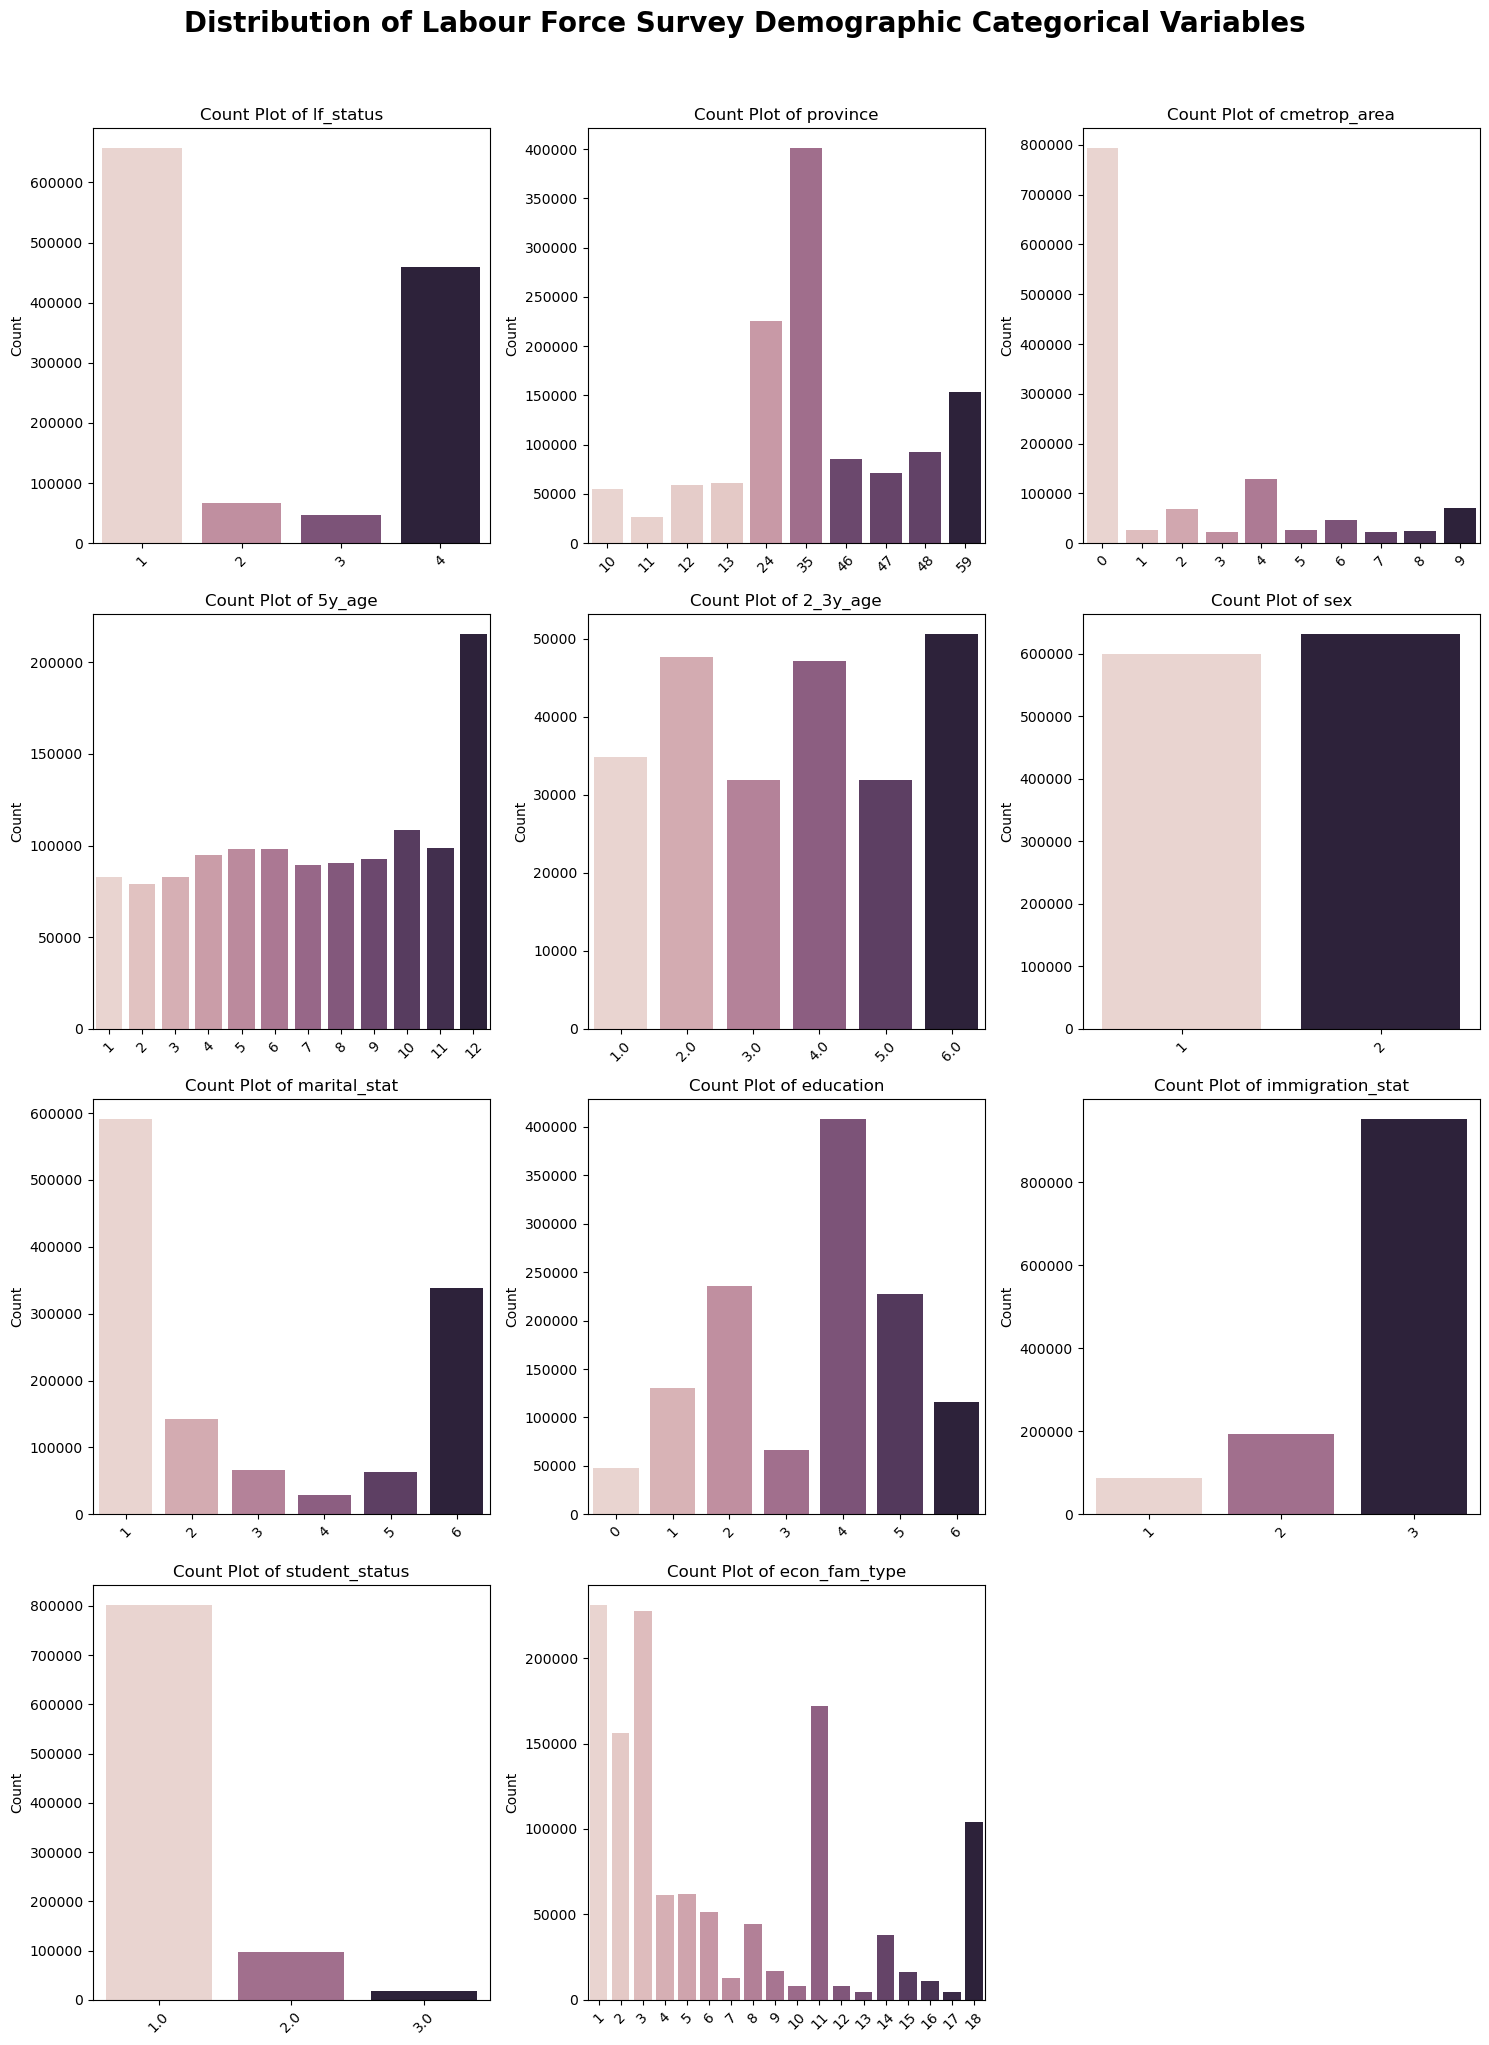

In [40]:
# Define grid size
num_vars = len(demo_col)
cols = 3  # Number of columns in the grid
rows = -(-num_vars // cols)  # Ceiling division to get number of rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot count plots for each categorical variable
for i, col in enumerate(demo_col):
    sns.countplot(x=LFS_demo[col], ax=axes[i], hue=LFS_demo[col], legend=False)
    axes[i].set_title(f"Count Plot of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)  # Rotate labels if needed

# # Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribution of Labour Force Survey Demographic Categorical Variables", fontsize=20, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

##### Employed & At Work (Labour Force Status Category 1)

In [239]:
numerical_employed = ['usualhrs_main', 'actualhrs_main', 'usualhrs_all', 'actualhrs_all', 'hrs_away', 'hrs_overtime', 'paid_overtime',
                      'unpaid_overtime', 'current_tenure', 'hourly_wage']

categorical_employed = ['multiple_jobh', 'main_class_worker', 'NAICS_21', 'NOC_10', 'NOC_43', 'ft_pt_main', 'rsn_away', 'rsn_pt', 
                       'estab_size', 'firm_size', 'job_permenancy', 'union_stat']

employed_col = ['lf_status', 'multiple_jobh', 'main_class_worker', 'NAICS_21', 'NOC_10', 'NOC_43', 'usualhrs_main', 'actualhrs_main', 
                'ft_pt_main', 'usualhrs_all', 'actualhrs_all', 'hrs_away', 'rsn_away', 'hrs_overtime', 'paid_overtime', 'unpaid_overtime', 
                'rsn_pt', 'current_tenure', 'estab_size', 'firm_size', 'job_permenancy', 'union_stat', 'hourly_wage']

LFS_employed = LFS.loc[LFS['lf_status'] == 1, employed_col]
LFS_employed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 657089 entries, 2 to 1230966
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   lf_status          657089 non-null  int64  
 1   multiple_jobh      657089 non-null  float64
 2   main_class_worker  657089 non-null  float64
 3   NAICS_21           657089 non-null  float64
 4   NOC_10             657089 non-null  float64
 5   NOC_43             657089 non-null  float64
 6   usualhrs_main      657089 non-null  float64
 7   actualhrs_main     657089 non-null  float64
 8   ft_pt_main         657089 non-null  float64
 9   usualhrs_all       657089 non-null  float64
 10  actualhrs_all      657089 non-null  float64
 11  hrs_away           570354 non-null  float64
 12  rsn_away           92546 non-null   float64
 13  hrs_overtime       570354 non-null  float64
 14  paid_overtime      570354 non-null  float64
 15  unpaid_overtime    570354 non-null  float64
 16  rsn_pt

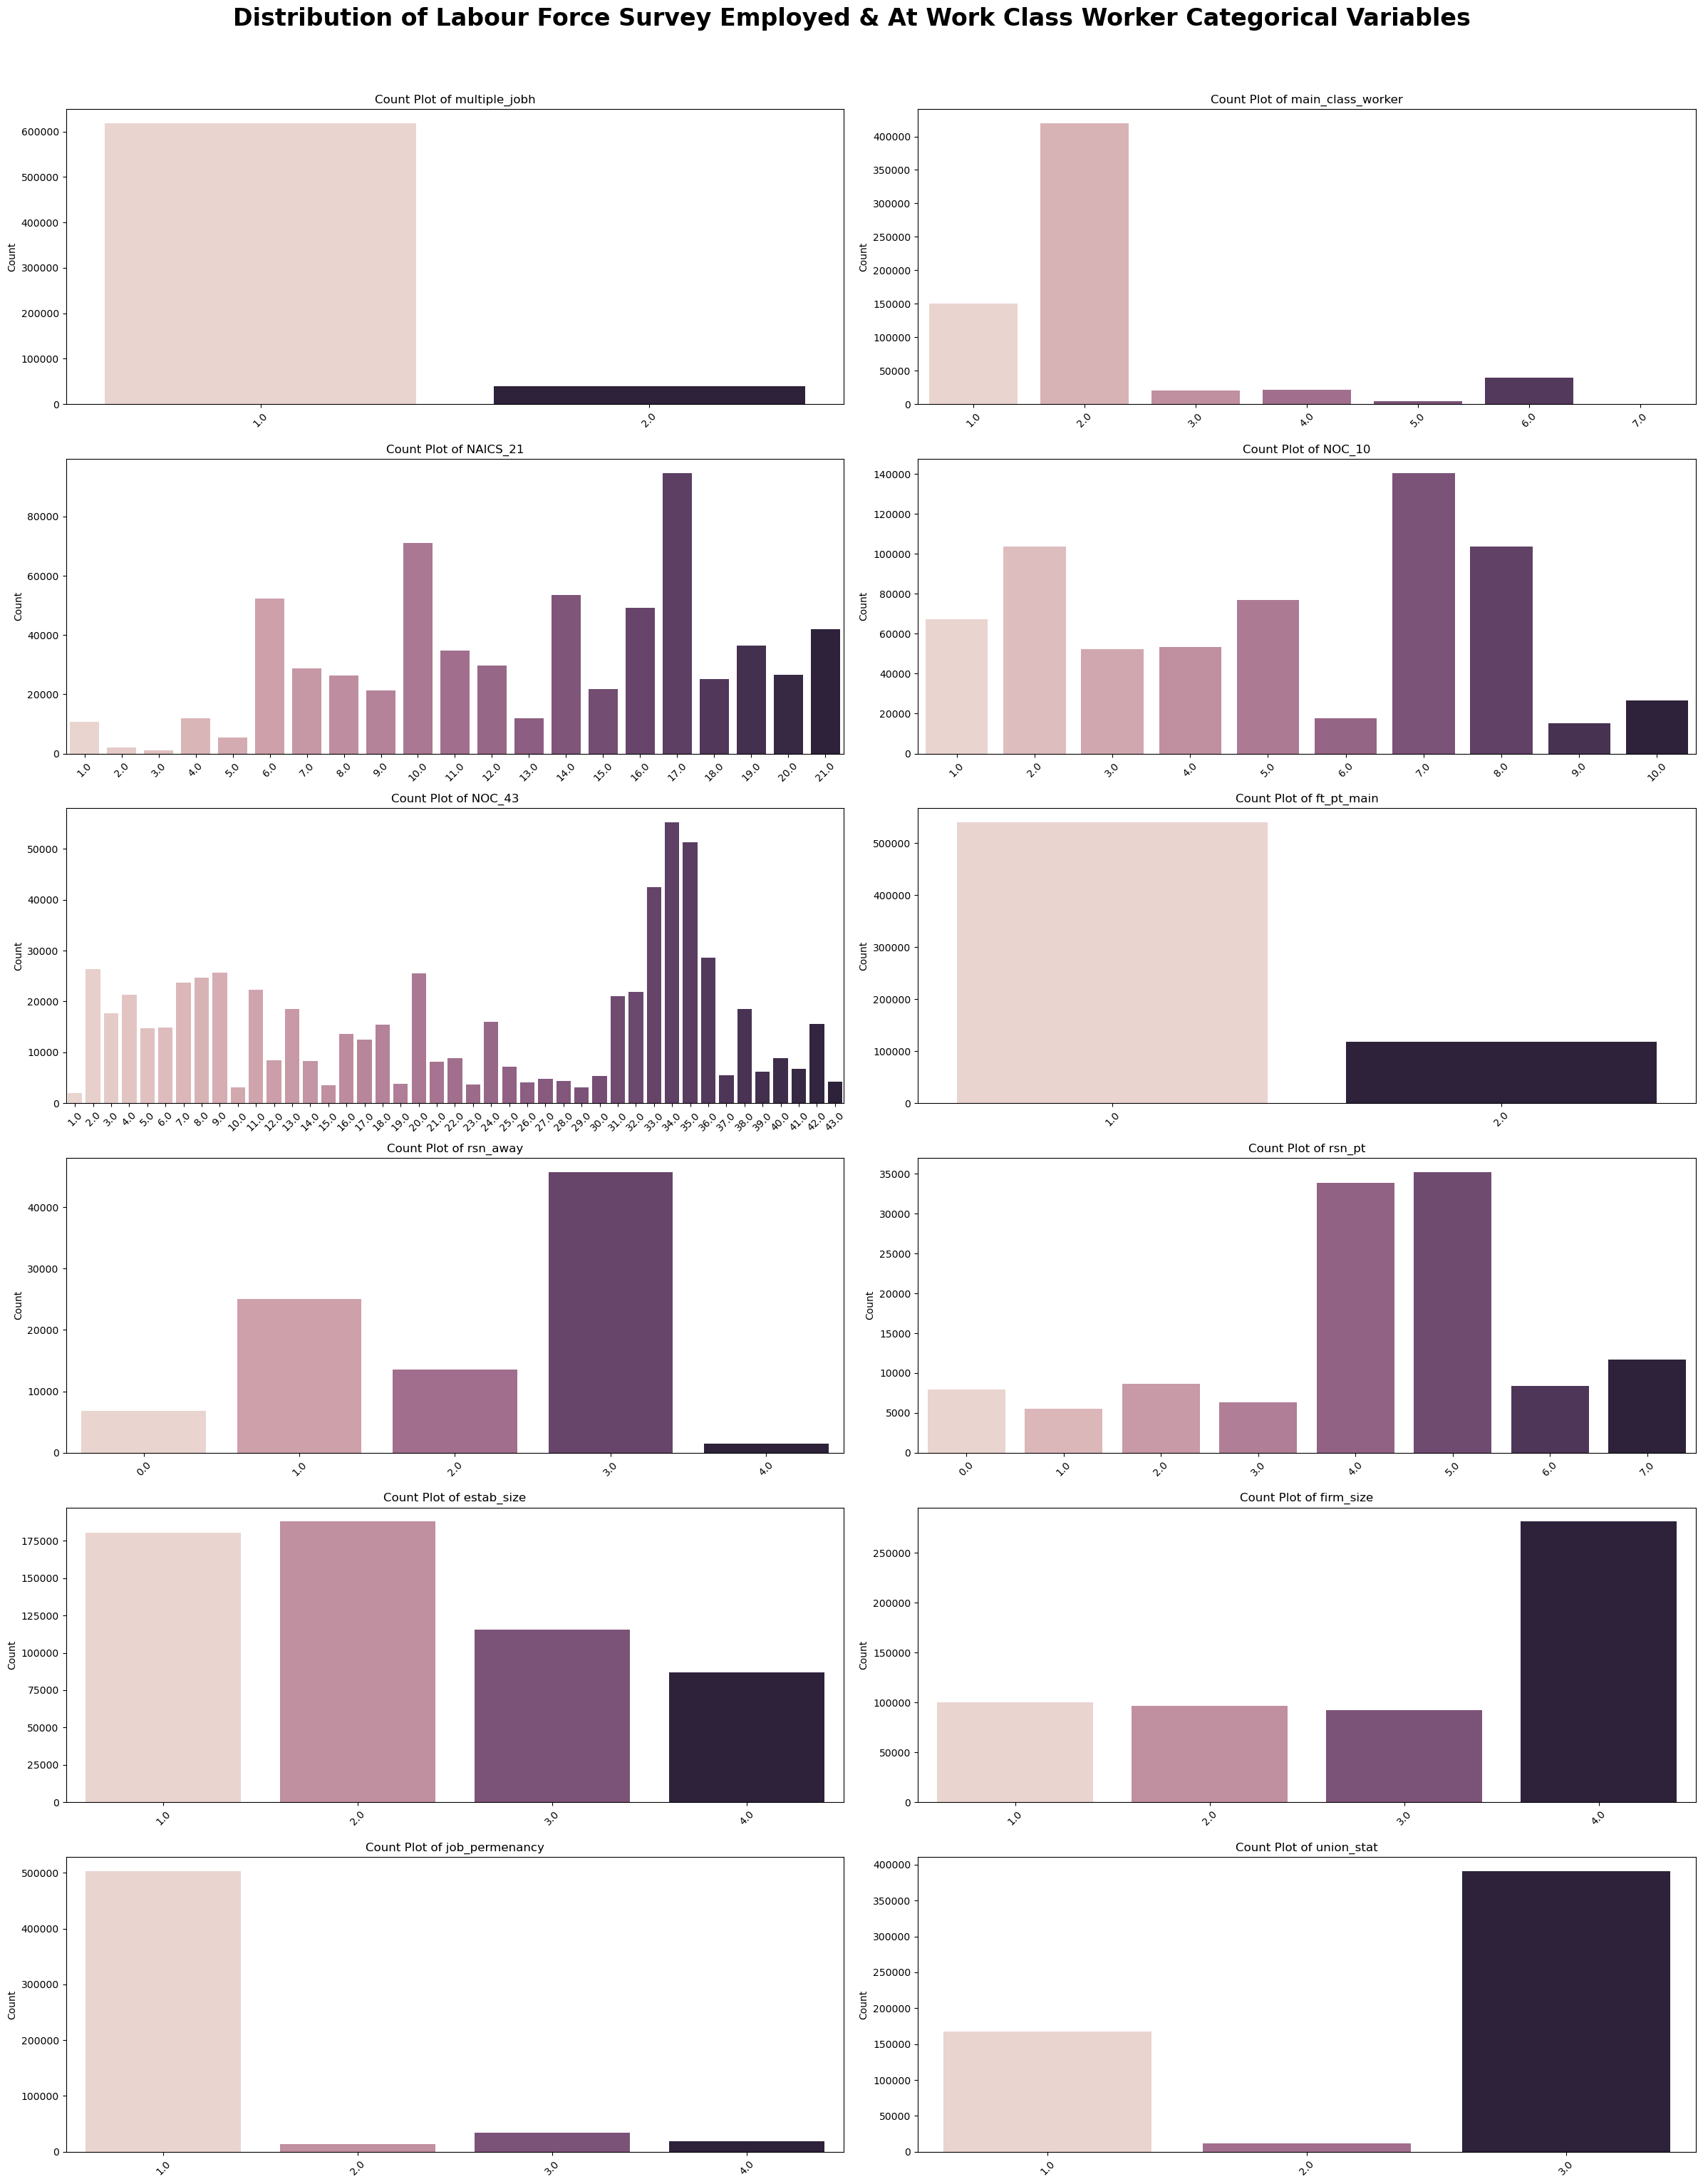

In [111]:
# Define grid size
num_vars = len(categorical_employed)
cols = 2  # Number of columns in the grid
rows = -(-num_vars // cols)  # Ceiling division to get number of rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(24, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot count plots for each categorical variable
for i, col in enumerate(categorical_employed):
    sns.countplot(x=LFS_employed[col], ax=axes[i], hue=LFS_employed[col], legend=False)
    axes[i].set_title(f"Count Plot of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)  # Rotate labels if needed

# # Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribution of Labour Force Survey Employed & At Work Class Worker Categorical Variables", fontsize=24, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

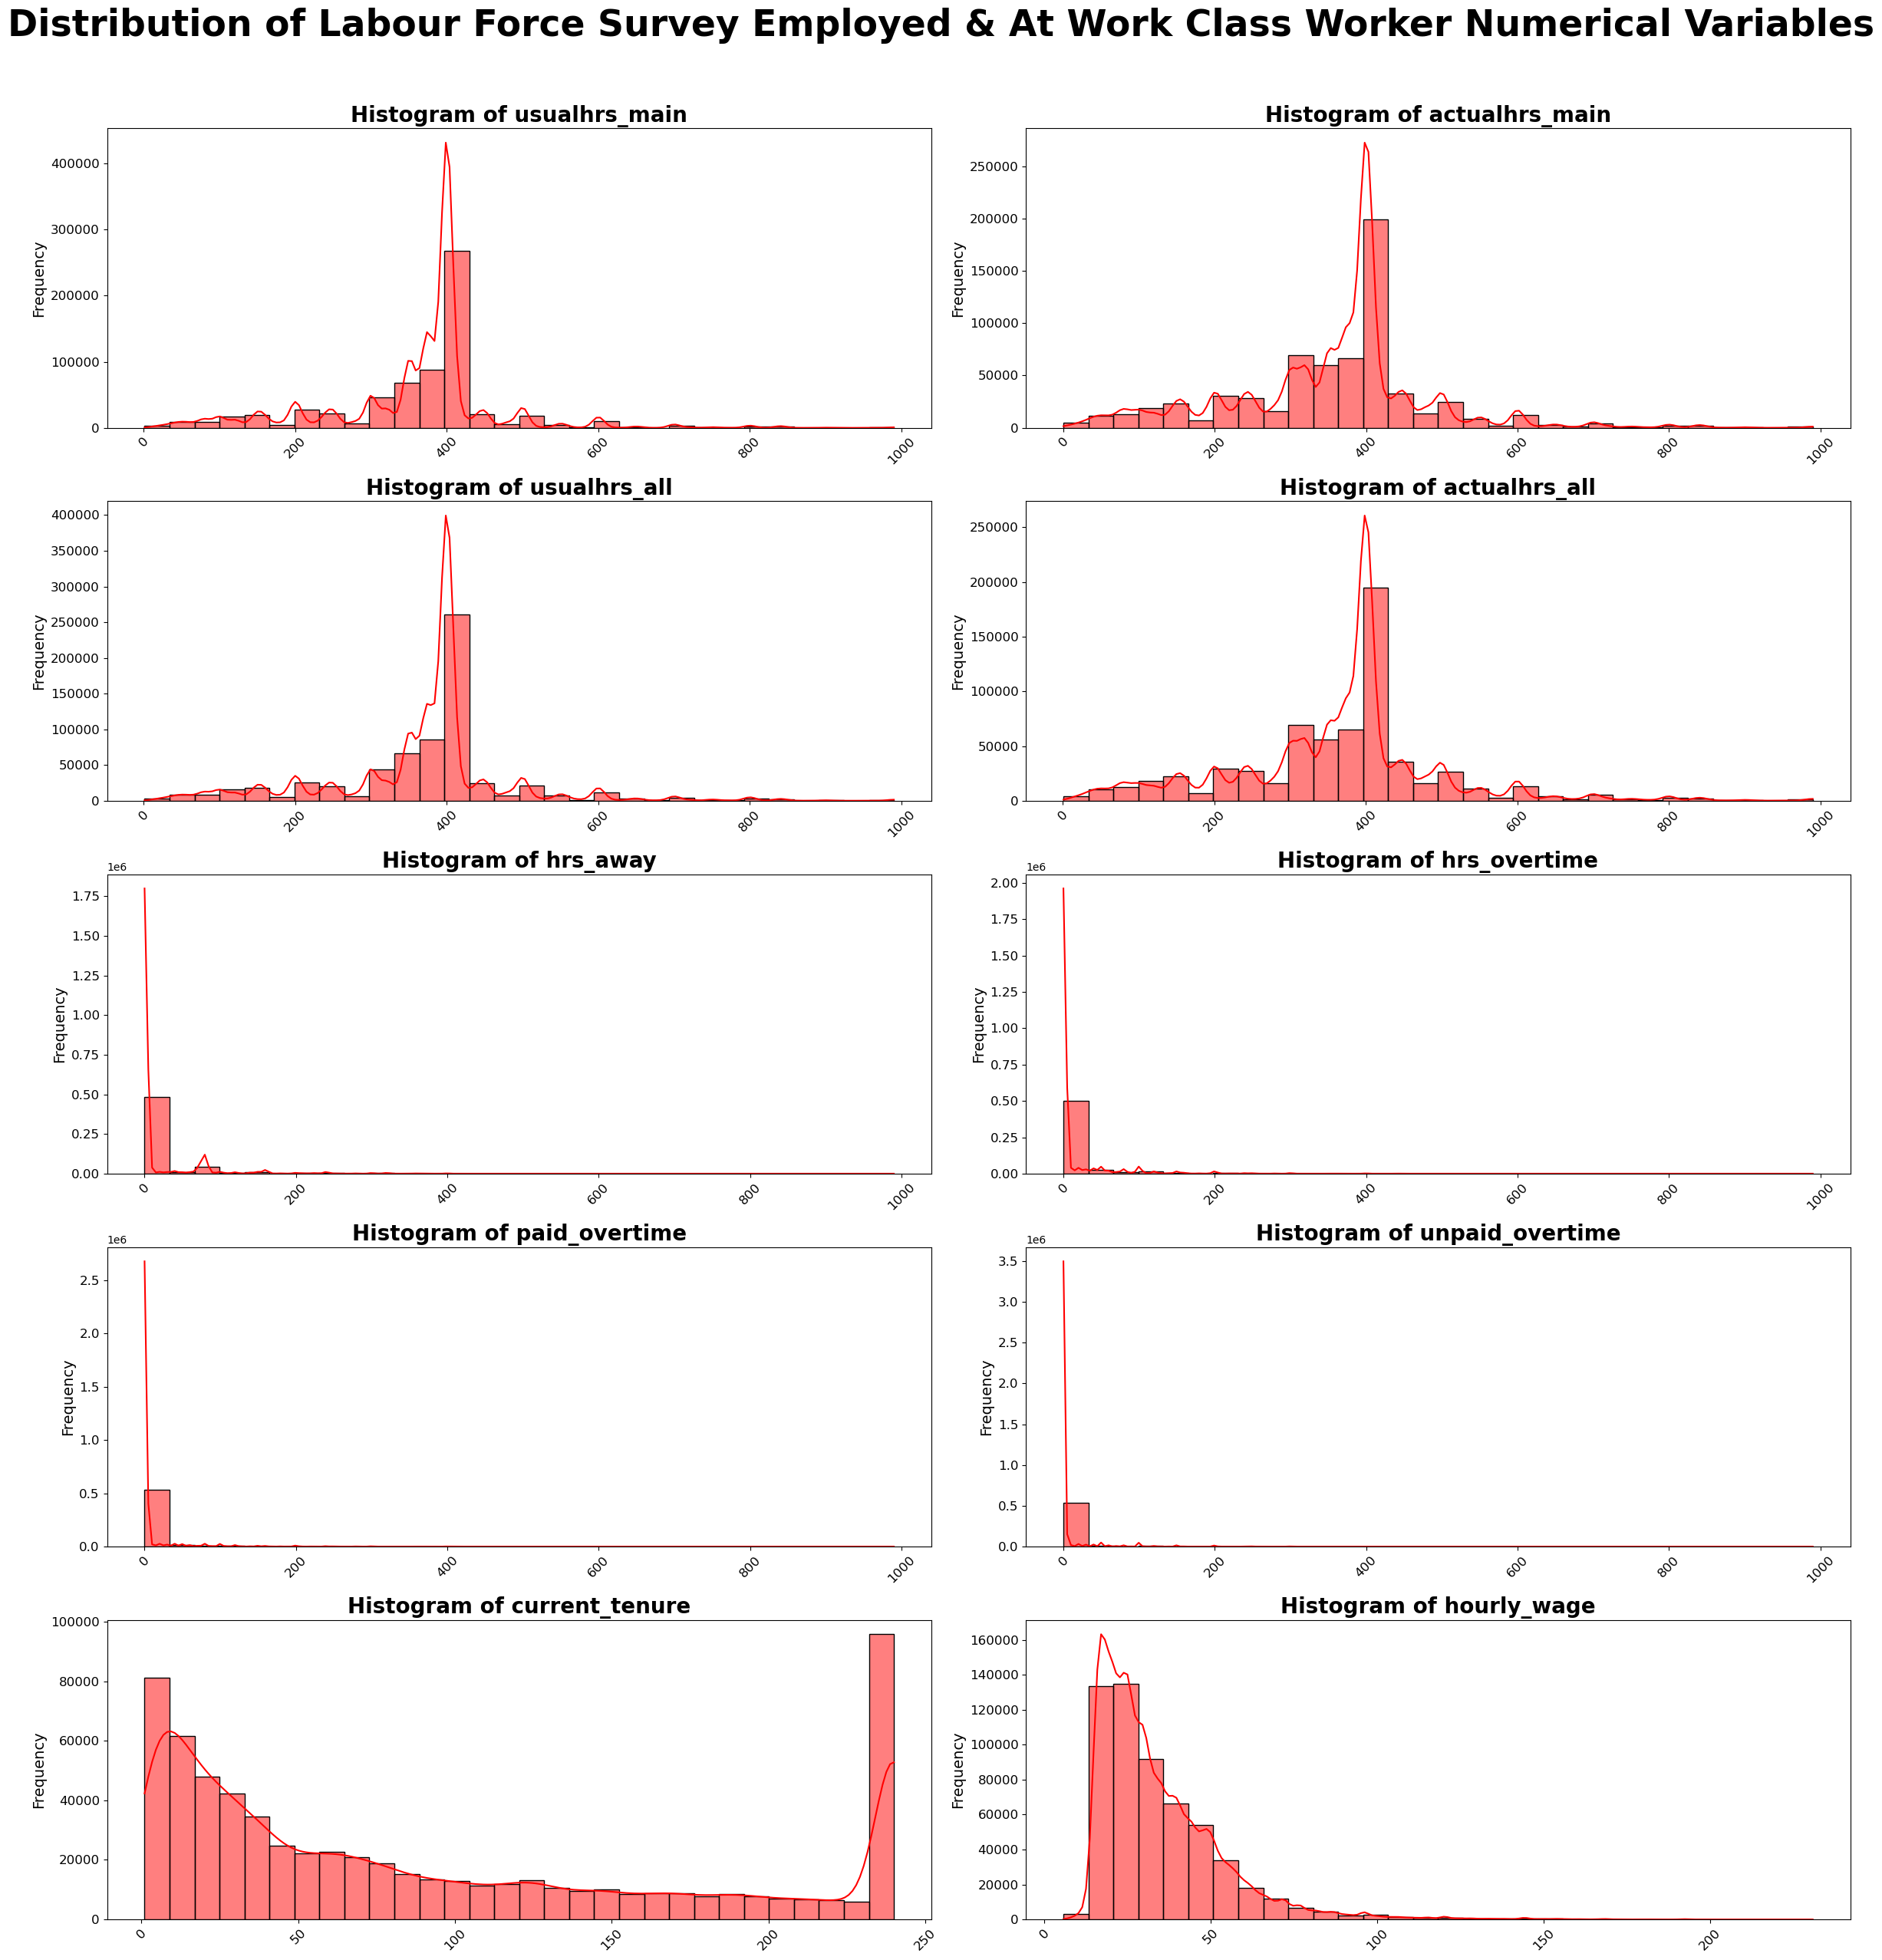

In [241]:
# Define grid size
num_vars = len(numerical_employed)  # List of numerical columns
cols = 2  # Number of columns in the grid
rows = -(-num_vars // cols)  # Ceiling division to get number of rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(24, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each numerical variable
for i, col in enumerate(numerical_employed):
    sns.histplot(LFS_employed[col], ax=axes[i], kde=True, color='red', bins=30)
    axes[i].set_title(f"Histogram of {col}", fontsize=20, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=14)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45, labelsize=12)  # Rotate labels and adjust size
    axes[i].tick_params(axis="y", labelsize=12)  # Adjust y-axis label size

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Add an overall title with adjusted size and padding
fig.suptitle("Distribution of Labour Force Survey Employed & At Work Class Worker Numerical Variables", 
             fontsize=34, fontweight="bold", y=1.02)

# Adjust tight layout to fit everything
plt.tight_layout()
plt.show()


In [65]:
LFS_employed.isnull().sum()

lf_status                 0
multiple_jobh             0
main_class_worker         0
NAICS_21                  0
NOC_10                    0
NOC_43                    0
usualhrs_main             0
actualhrs_main            0
ft_pt_main                0
usualhrs_all              0
actualhrs_all             0
hrs_away              86735
rsn_away             564543
hrs_overtime          86735
paid_overtime         86735
unpaid_overtime       86735
rsn_pt               539559
current_tenure            0
estab_size            86735
firm_size             86735
job_permenancy        86735
union_stat            86735
hourly_wage           86735
dtype: int64

In [82]:
print(LFS_employed['main_class_worker'].value_counts().sort_index())

num_employees = LFS_employed['main_class_worker'].value_counts().sort_index().iloc[0:2].sum()
num_self_employed = LFS_employed['main_class_worker'].value_counts().sort_index().iloc[2:6].sum()
num_family_worker = LFS_employed['main_class_worker'].value_counts().sort_index().iloc[6]

print(f'\nNumber of employees: {num_employees}')
print(f'Number of self-employed or unpaid family workers: {num_self_employed + num_family_worker}')
print("""The variables hrs_away, hrs_overtime, paid_overtime, unpaid_overtime, estab_size, firm_size, job_permenancy, union_stat, hourly_wage 
with missing values equal to 86,735 are missing by design. These columns were directed at respondents who are currently employees. 
Self-employed and unpaid family workers were not required to answer the survey questions. Therefore, the missing values are due to survey 
design and the null values are due to the inapplicability of the column to the respondent.""")

main_class_worker
1.0    150669
2.0    419685
3.0     20505
4.0     21241
5.0      4687
6.0     39787
7.0       515
Name: count, dtype: int64

Number of employees: 570354
Number of self-employed or unpaid family workers: 86735
The variables hrs_away, hrs_overtime, paid_overtime, unpaid_overtime, estab_size, firm_size, job_permenancy, union_stat, hourly_wage 
with missing values equal to 86,735 are missing by design. These columns were directed at respondents who are currently employees. 
Self-employed and unpaid family workers were not required to answer the survey questions. Therefore, the missing values are due to survey 
design and the null values are due to the inapplicability of the column to the respondent.


In [63]:
print(LFS_employed['ft_pt_main'].value_counts().sort_index())

print(f"""The number of missing values in variable 'rsn_pt' corresponds to the number of full-time 
respondents in variable 'ft_pt_main' in category 1 = {LFS_employed['ft_pt_main'].value_counts().sort_index().loc[1]}. This indicates
that the missing values are due to survey design and the null values are due to the inapplicability of the column to the respondent.""")

ft_pt_main
1.0    539559
2.0    117530
Name: count, dtype: int64
The number of missing values in variable 'rsn_pt' corresponds to the number of full-time 
respondents in variable 'ft_pt_main' in category 1 = 539559. This indicates
that the missing values are due to survey design and the null values are due to the inapplicability of the column to the respondent.


In [196]:
LFS_employed.groupby(['main_class_worker'])[['rsn_away', 'hrs_away']].apply(lambda x: x.isnull().sum())

,rsn_away,hrs_away
main_class_worker,,
1.0,119411,0
2.0,358397,0
3.0,20505,20505
4.0,21241,21241
5.0,4687,4687
6.0,39787,39787
7.0,515,515


In [206]:
# Check how many rows have hrs_away = 0 and rsn_away is NULL
missing_by_design = ((LFS_employed['hrs_away'] == 0) & (LFS_employed['rsn_away'].isnull())).sum()

# Check how many rows have hrs_away > 0
count_non_zero = (LFS_employed['hrs_away'] > 0).sum()

# Check how many rows have hrs_away > 0 and rsn_away is NULL (unexpected missingness)
random_missing = ((LFS_employed['hrs_away'] > 0) & (LFS_employed['rsn_away'].isnull())).sum()

print(f'\nNumber of employees: {num_employees}')
print(f"Number of observations in 'hrs_away' that are not 0: {count_non_zero}")
print(f"Number of missing rsn_away values where hrs_away = 0 (Missing by Design): {missing_by_design}")
print(f"Number of missing rsn_away values where hrs_away > 0 (Unexpected Missingness): {random_missing}")
print(f'Number of self-employed or unpaid family workers: {num_self_employed + num_family_worker}')
print(f'''Total null entries in rsn_away column: {LFS_employed['rsn_away'].isnull().sum()}''')

print("""\nThe purpose of variable rsn_away is for employees who are at work and have been absent for part of the week to provide a reason
for their absence. Employees who have not been absent (477,808) were required to fill the hrs_away portion with 0 as it had no 
'not applicable' option. Whereas the variable rsn_away did have an option for 'not_applicable'. In addition, self-employed and 
unpaid family workers are not considered employees at work and therefore were not required to answer the survey question.""")

print(f"""\nTherefore if we sum the numbers of missing by design, self-employed, and unpaid family workers: {missing_by_design + num_self_employed + num_family_worker}
it corresponds with the total number of null values in the rsn_away column. Therefore, the missing values are by design. """)


Number of employees: 570354
Number of observations in 'hrs_away' that are not 0: 92546
Number of missing rsn_away values where hrs_away = 0 (Missing by Design): 477808
Number of missing rsn_away values where hrs_away > 0 (Unexpected Missingness): 0
Number of self-employed or unpaid family workers: 86735
Total null entries in rsn_away column: 564543

The purpose of variable rsn_away is for employees who are at work and have been absent for part of the week to provide a reason
for their absence. Employees who have not been absent (477,808) were required to fill the hrs_away portion with 0 as it had no 
'not applicable' option. Whereas the variable rsn_away did have an option for 'not_applicable'. In addition, self-employed and 
unpaid family workers are not considered employees at work and therefore were not required to answer the survey question.

Therefore if we sum the numbers of missing by design, self-employed, and unpaid family workers: 
5811
it corresponds with the total number o

#### Employed But Absent From Work (Labour Force Status Category 2)

In [243]:
absent_col = ['lf_status', 'multiple_jobh', 'main_class_worker', 'NAICS_21', 'NOC_10', 'NOC_43', 'rsn_absent_fullwk', 'weeks_absent',
                       'paid_for_absence', 'usualhrs_main', 'actualhrs_main', 'ft_pt_main', 'usualhrs_all', 'actualhrs_all', 
                       'rsn_pt', 'current_tenure', 'estab_size', 'firm_size', 'job_permenancy', 'union_stat', 'hourly_wage']

numerical_absent = ['usualhrs_main', 'actualhrs_main', 'usualhrs_all', 'actualhrs_all', 'weeks_absent', 'current_tenure', 'hourly_wage']

categorical_absent = ['multiple_jobh', 'main_class_worker', 'NAICS_21', 'NOC_10', 'NOC_43', 'ft_pt_main', 'rsn_absent_fullwk', 'paid_for_absence', 
                      'rsn_pt', 'estab_size', 'firm_size', 'job_permenancy', 'union_stat']
                    
LFS_absent = LFS.loc[LFS['lf_status'] == 2, absent_col]
LFS_absent.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66782 entries, 11 to 1230958
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   lf_status          66782 non-null  int64  
 1   multiple_jobh      66782 non-null  float64
 2   main_class_worker  66782 non-null  float64
 3   NAICS_21           66782 non-null  float64
 4   NOC_10             66782 non-null  float64
 5   NOC_43             66782 non-null  float64
 6   rsn_absent_fullwk  66782 non-null  float64
 7   weeks_absent       66782 non-null  float64
 8   paid_for_absence   60592 non-null  float64
 9   usualhrs_main      66782 non-null  float64
 10  actualhrs_main     66782 non-null  float64
 11  ft_pt_main         66782 non-null  float64
 12  usualhrs_all       66782 non-null  float64
 13  actualhrs_all      66782 non-null  float64
 14  rsn_pt             13620 non-null  float64
 15  current_tenure     66782 non-null  float64
 16  estab_size         56817

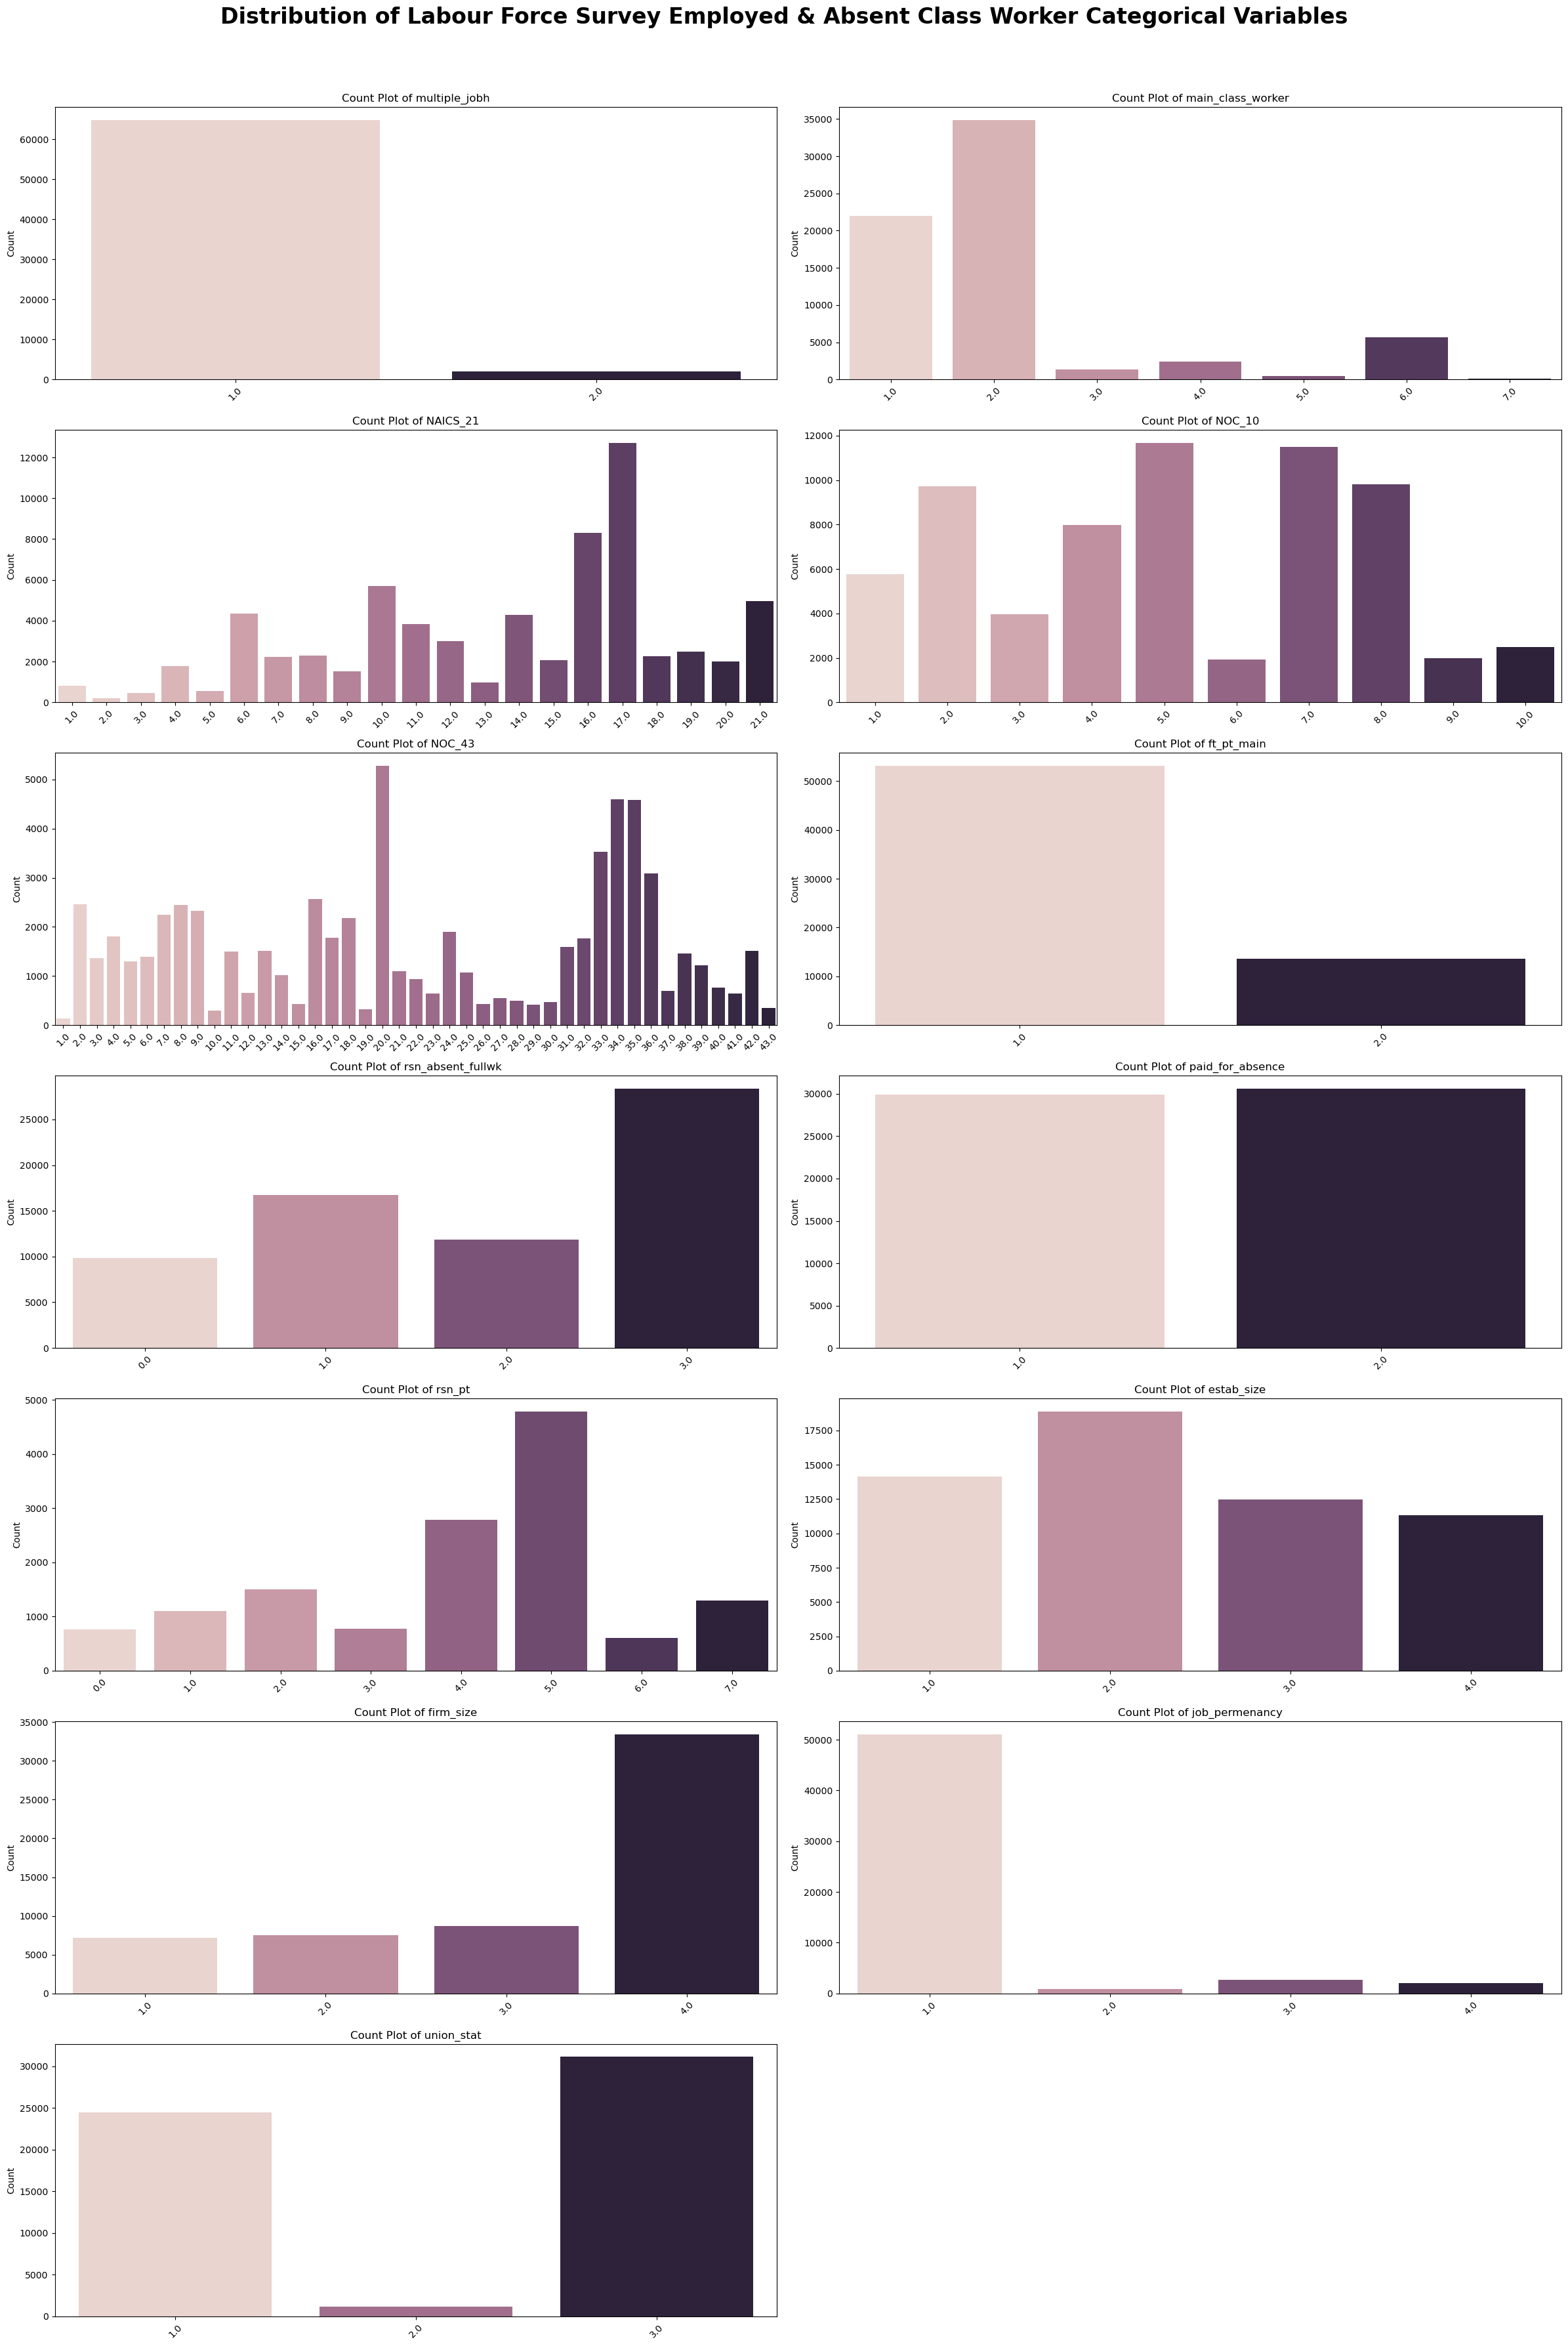

In [219]:
# Define grid size
num_vars = len(categorical_absent)
cols = 2  # Number of columns in the grid
rows = -(-num_vars // cols)  # Ceiling division to get number of rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(24, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot count plots for each categorical variable
for i, col in enumerate(categorical_absent):
    sns.countplot(x=LFS_absent[col], ax=axes[i], hue=LFS_absent[col], legend=False)
    axes[i].set_title(f"Count Plot of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)  # Rotate labels if needed

# # Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Distribution of Labour Force Survey Employed & Absent Class Worker Categorical Variables", fontsize=24, fontweight="bold", y=1.02)

plt.tight_layout()
plt.show()

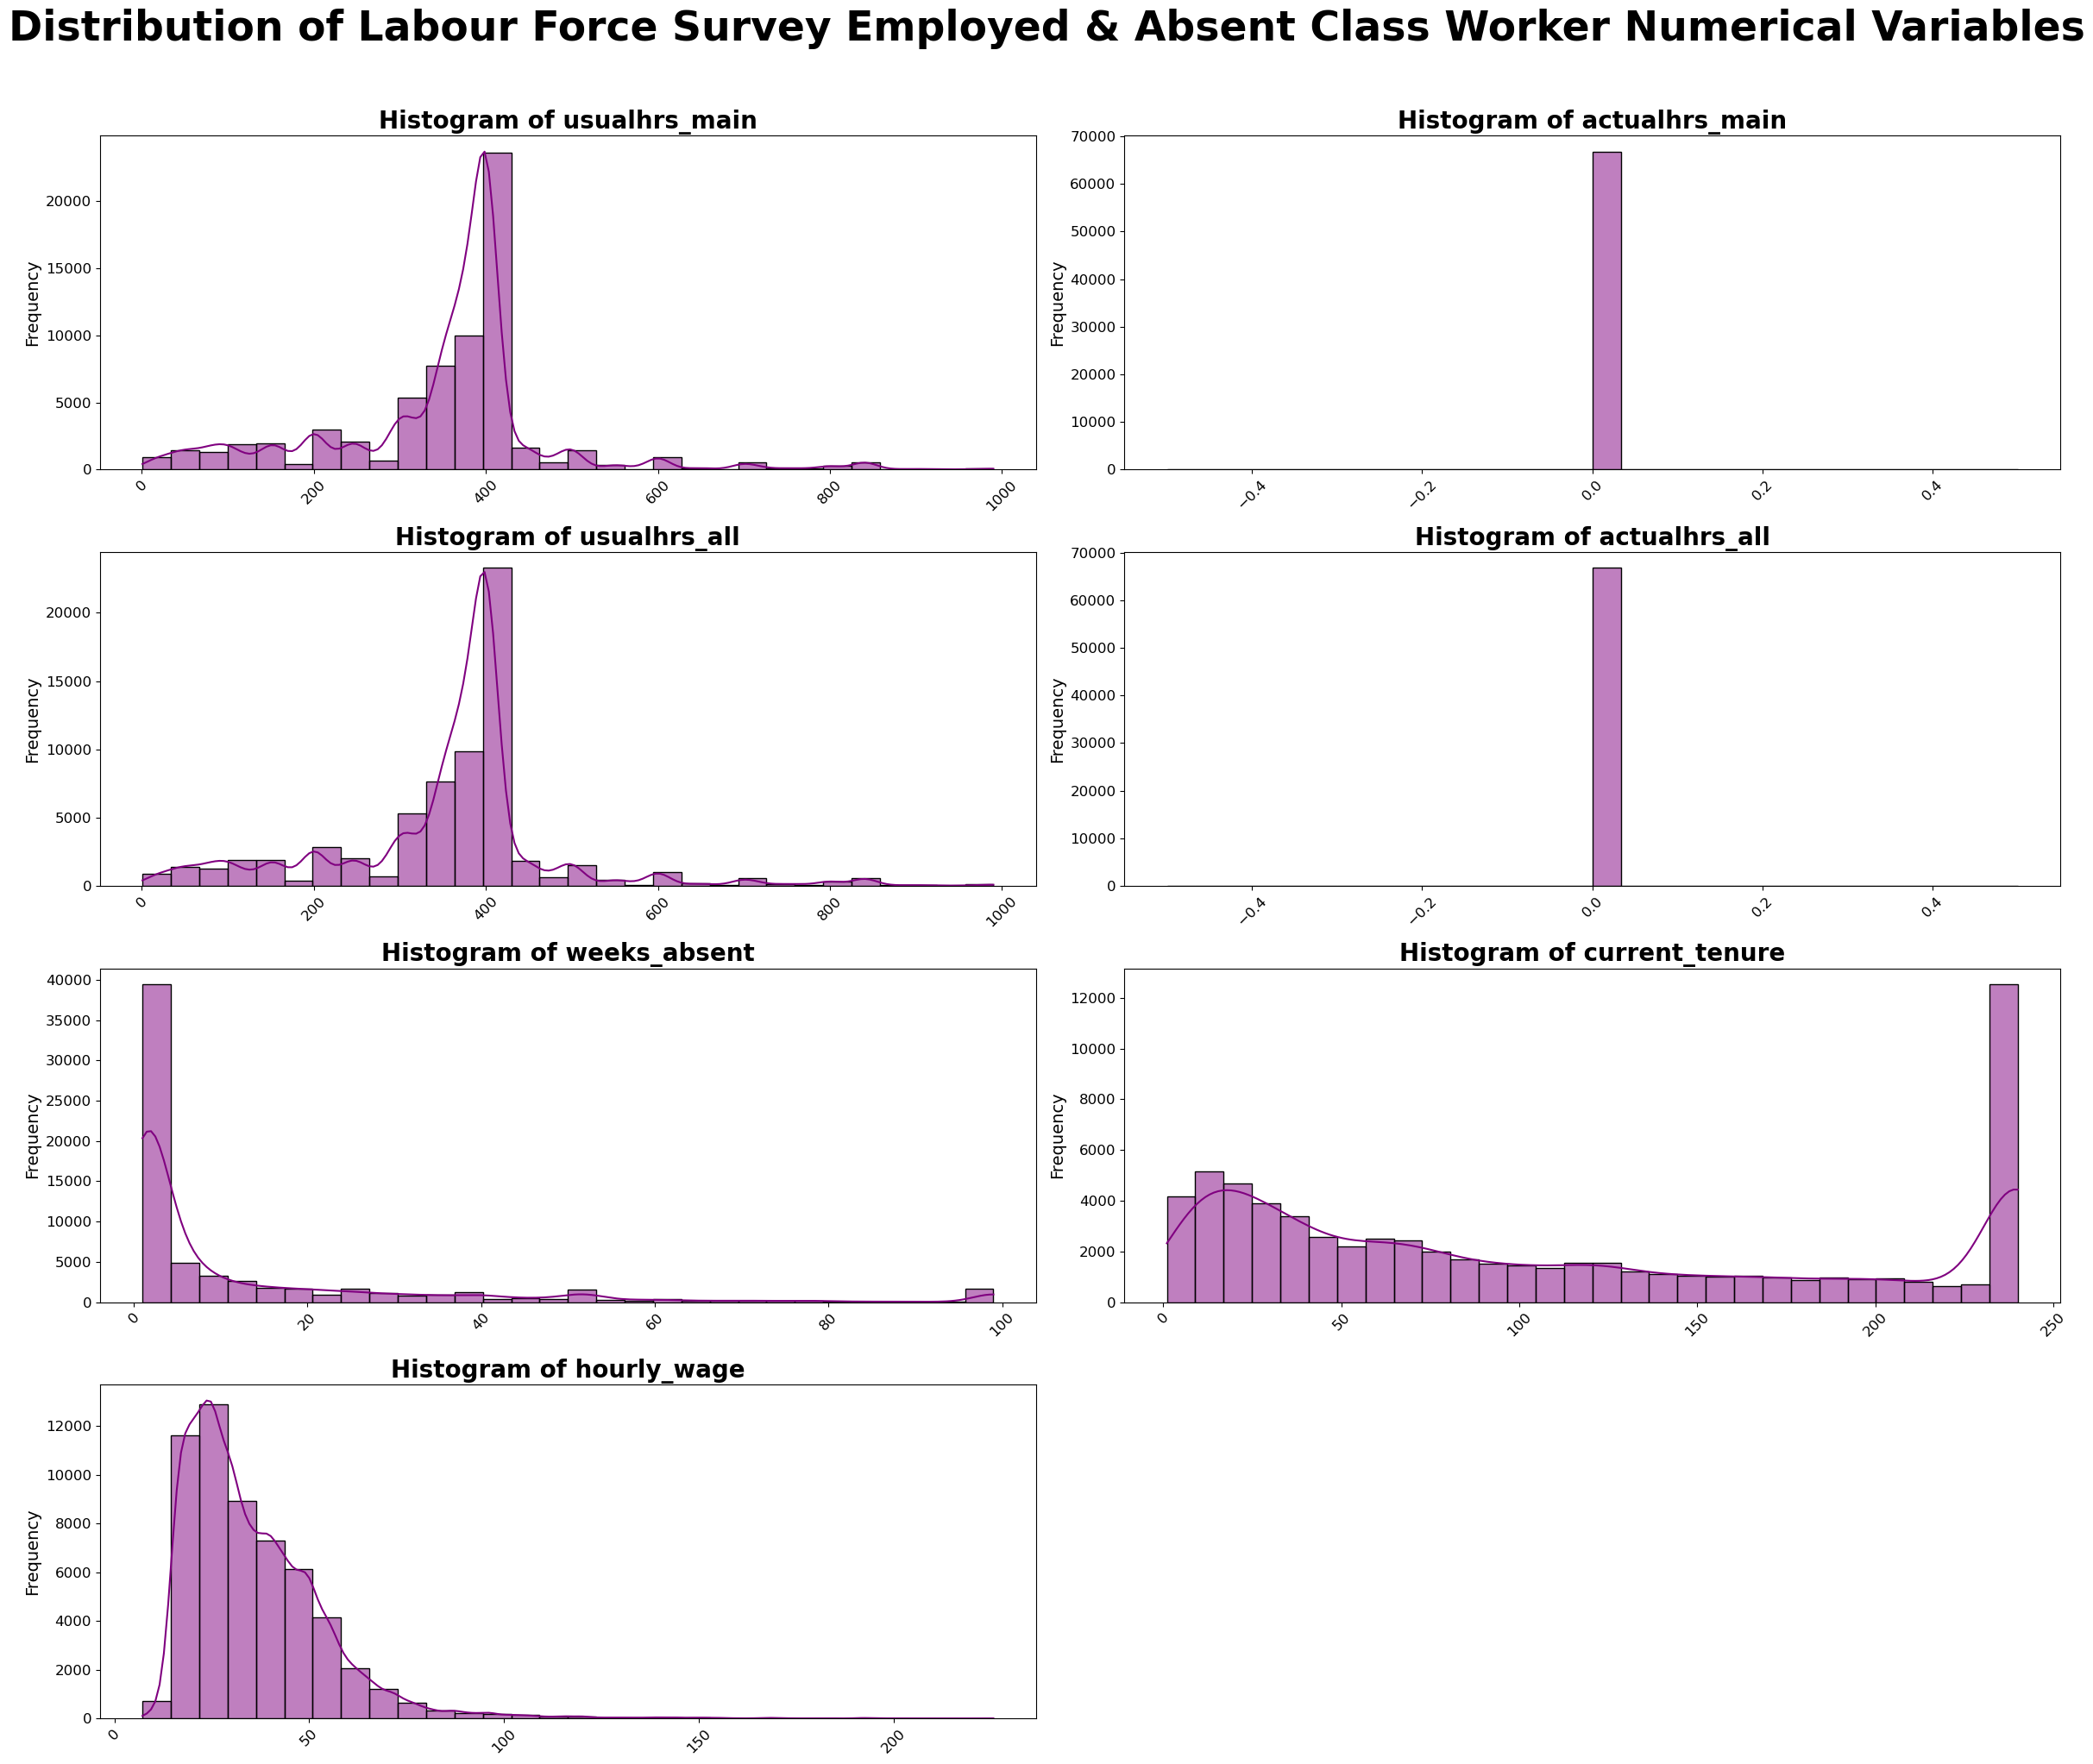

In [245]:
# Define grid size
num_vars = len(numerical_absent)  # List of numerical columns
cols = 2  # Number of columns in the grid
rows = -(-num_vars // cols)  # Ceiling division to get number of rows

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(24, 5 * rows))

# Flatten axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each numerical variable
for i, col in enumerate(numerical_absent):
    sns.histplot(LFS_absent[col], ax=axes[i], kde=True, color='purple', bins=30)
    axes[i].set_title(f"Histogram of {col}", fontsize=20, fontweight="bold")
    axes[i].set_ylabel("Frequency", fontsize=14)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=45, labelsize=12)  # Rotate labels and adjust size
    axes[i].tick_params(axis="y", labelsize=12)  # Adjust y-axis label size

# Hide any empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# Add an overall title with adjusted size and padding
fig.suptitle("Distribution of Labour Force Survey Employed & Absent Class Worker Numerical Variables", 
             fontsize=34, fontweight="bold", y=1.02)

# Adjust tight layout to fit everything
plt.tight_layout()
plt.show()


In [247]:
LFS_absent.isnull().sum()


lf_status                0
multiple_jobh            0
main_class_worker        0
NAICS_21                 0
NOC_10                   0
NOC_43                   0
rsn_absent_fullwk        0
weeks_absent             0
paid_for_absence      6190
usualhrs_main            0
actualhrs_main           0
ft_pt_main               0
usualhrs_all             0
actualhrs_all            0
rsn_pt               53162
current_tenure           0
estab_size            9965
firm_size             9965
job_permenancy        9965
union_stat            9965
hourly_wage           9965
dtype: int64

In [249]:
print(LFS_absent['ft_pt_main'].value_counts().sort_index())

print(f"""The number of missing values in variable 'rsn_pt' corresponds to the number of full-time 
respondents in variable 'ft_pt_main' in category 1 = {LFS_absent['ft_pt_main'].value_counts().sort_index().loc[1]}. This indicates
that the missing values are due to survey design and the null values are due to the inapplicability of the column to the respondent.""")

ft_pt_main
1.0    53162
2.0    13620
Name: count, dtype: int64
The number of missing values in variable 'rsn_pt' corresponds to the number of full-time 
respondents in variable 'ft_pt_main' in category 1 = 53162. This indicates
that the missing values are due to survey design and the null values are due to the inapplicability of the column to the respondent.


## Job Vacancy by Industry 

## Consumer Price Index